In [1]:
import numpy as np
import pandas as pd

import scarf

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr")
run = ds.pipeline.open(label="docs_default")
clusters = run["clusters"]
markers = run["markers"]
cluster_values = run.cells.fetch("clusters").astype(str)

Downloading bucket files: 56215324 / 56215324 complete

Downloading bytes: 56215324 / 56215324 complete

In [2]:
group_markers = ds.get_markers(marker=markers, group_id="1")
group_markers[
    ["feature_name", "score", "frac_exp", "fold_change", "auc", "p_value_adjusted"]
].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value_adjusted
0,S100A12,0.95617,0.93994,815.52981,0.96916,0.0
1,VCAN,0.92713,0.96648,360.28912,0.98244,0.0
2,CD14,0.92068,0.95251,419.17110,0.97550,0.0
3,ALDH1A1,0.90752,0.51816,646.32933,0.75854,0.0
4,CLEC4E,0.90587,0.58659,834.76424,0.79282,0.0
5,LGALS2,0.90344,0.55587,243.49814,0.77642,0.0
6,CD163,0.89379,0.50419,433.35070,0.75137,0.0
7,QPCT,0.88405,0.46788,370.17063,0.73317,0.0
8,CYP27A1,0.88355,0.46648,363.40352,0.73234,0.0
9,STAB1,0.87829,0.62430,93.18504,0.80792,0.0


INFO: execution countsRowBlock: read=1/1 compute=1/1 write=1/1 fetch=0.00s compute=0.00s readerWait=0.00s computeWait=0.00s held=0 reason=1 compute workers used because there are 1 units


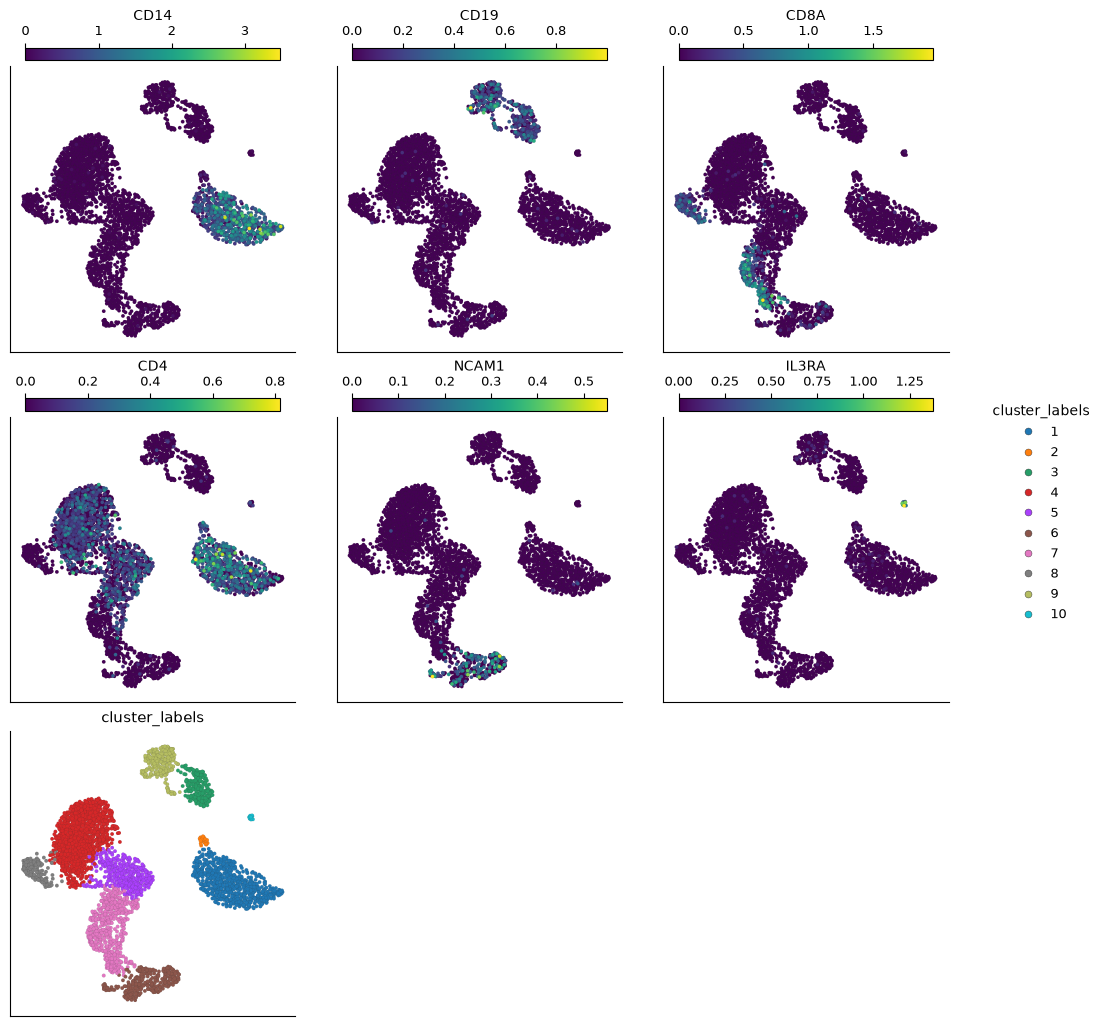

In [3]:
panel_genes = ["CD14", "CD19", "CD8A", "CD4", "NCAM1", "IL3RA"]
ds.plots.embedding(
    layout=run["umap"],
    color_by=[*panel_genes, clusters],
    n_columns=3,
    sort_values=True,
)

In [4]:
all_markers = ds.get_markers(marker=markers, min_score=-1, min_frac_exp=-1)
panel_stats = all_markers[all_markers["feature_name"].isin(panel_genes)]
panel_best = (
    panel_stats.sort_values("score", ascending=False)
    .groupby("feature_name", sort=False)
    .head(1)
    .set_index("feature_name")
    .reindex(panel_genes)
)
panel_best[["group_id", "score", "frac_exp", "auc"]].round(2)

,group_id,score,frac_exp,auc
feature_name,,,,
CD14,1,0.92,0.95,0.98
CD19,9,0.54,0.61,0.78
CD8A,8,0.51,0.87,0.88
CD4,1,0.33,0.75,0.77
NCAM1,6,0.76,0.40,0.70
IL3RA,10,0.81,1.00,1.00


In [5]:
proposed_labels = {
    "1": "CD14 monocytes",
    "2": "monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "T cells",
    "6": "NK cells",
    "7": "T cells",
    "8": "T cells",
    "9": "B cells",
    "10": "pDC-like cells",
}
pd.Series(proposed_labels, name="proposed_cell_type")

1     CD14 monocytes
2          monocytes
3            B cells
4            T cells
5            T cells
6           NK cells
7            T cells
8            T cells
9            B cells
10    pDC-like cells
Name: proposed_cell_type, dtype: str

Aggregating marker values per group: 1 / 1 complete

INFO: execution countsRowBlock: read=1/1 compute=1/1 write=1/1 fetch=0.00s compute=0.00s readerWait=0.00s computeWait=0.00s held=0 reason=1 compute workers used because there are 1 units


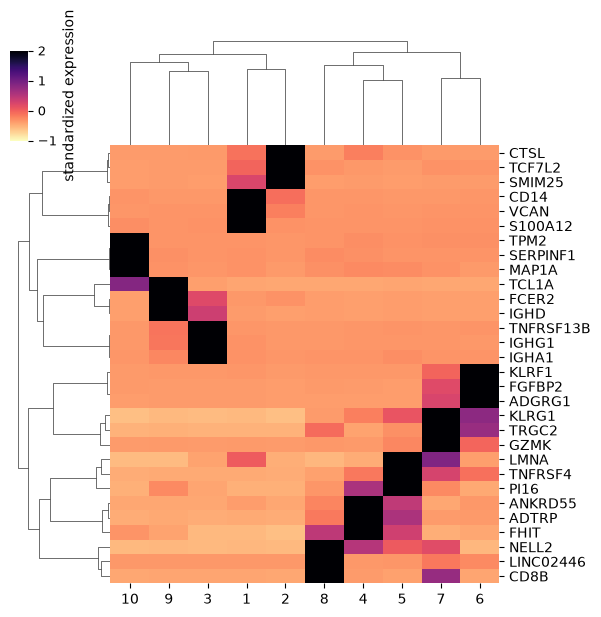

In [6]:
ds.plots.marker_heatmap(marker=markers, topn=3, figsize=(6, 6))

In [7]:
t_cell_genes = ["CD3D", "CD8A", "CD8B", "CCR7", "IL7R", "CD27", "GZMK"]
t_cell_evidence = all_markers[
    all_markers["group_id"].isin(["7", "8"])
    & all_markers["feature_name"].isin(t_cell_genes)
]
t_cell_evidence[["group_id", "feature_name", "frac_exp", "score"]].round(2)

,group_id,feature_name,frac_exp,score
201228,7,GZMK,0.72,0.83
201235,7,CD8A,0.43,0.39
201313,7,CD3D,0.98,0.26
201315,7,CD8B,0.41,0.26
201326,7,IL7R,0.76,0.25
202501,7,CD27,0.53,0.15
234263,7,CCR7,0.14,0.03
234767,8,CD8B,0.95,0.70
234769,8,CD8A,0.87,0.51
234793,8,CCR7,0.85,0.30


In [8]:
comparison_genes = ["CD3D", "CD3E", "CD4", "NKG7", "GNLY", "CD8A", "CD8B"]
comparison = all_markers[
    all_markers["group_id"].isin(["6", "8"])
    & all_markers["feature_name"].isin(comparison_genes)
]
comparison[
    ["group_id", "feature_name", "frac_exp", "frac_exp_rest", "auc"]
].round(2)

,group_id,feature_name,frac_exp,frac_exp_rest,auc
167700,6,GNLY,1.00,0.10,1.00
167731,6,NKG7,1.00,0.21,0.99
175505,6,CD3D,0.31,0.65,0.39
176657,6,CD3E,0.43,0.66,0.40
200042,6,CD8A,0.11,0.11,0.50
201125,6,CD4,0.02,0.39,0.31
201165,6,CD8B,0.00,0.12,0.44
234767,8,CD8B,0.95,0.08,0.95
234769,8,CD8A,0.87,0.08,0.88
234845,8,CD3E,0.99,0.63,0.70


In [9]:
final_labels = proposed_labels | {
    "3": "memory B cells",
    "5": "CD4+ T cells",
    "7": "CD8+ T cells",
    "8": "naive CD8 T cells",
    "9": "naive B cells",
}

In [10]:
analysis_cells = run.cells.fetch_all("I").astype(bool)
initial_cell_type = np.full(ds.cells.N, "Not analyzed", dtype=object)
reviewed_cell_type = np.full(ds.cells.N, "Not analyzed", dtype=object)
initial_cell_type[analysis_cells] = [proposed_labels[value] for value in cluster_values]
reviewed_cell_type[analysis_cells] = [final_labels[value] for value in cluster_values]
ds.cells.insert("proposed_cell_type", initial_cell_type, overwrite=True)
ds.cells.insert("reviewed_cell_type", reviewed_cell_type, overwrite=True)

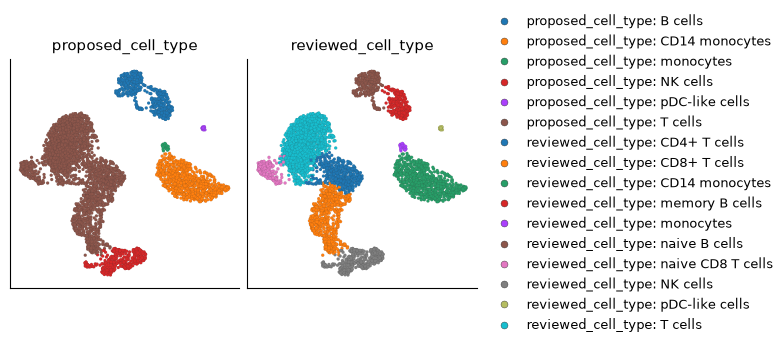

In [11]:
ds.plots.embedding(
    layout=run["umap"],
    color_by=["proposed_cell_type", "reviewed_cell_type"],
)